# Logistic Regression Implementation & Analysis
**Module:** `supervised.logistic_regression`  
**Dataset:** `agriculture.csv` (Crop Yield Classification)

---
In this notebook, we validate our custom Logistic Regression implementation using a synthetic toy dataset and then apply it to classify agricultural yield levels based on environmental and economic factors.

In [6]:
import sys
import os
# Adds the parent directory (root) to the path so we can find the 'src' folder
sys.path.append(os.path.abspath(".."))  

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn helpers for data preparation and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Your custom implementation
from src.my_ml_package.supervised.logistic_regression import LogisticRegression

# Setting seed for reproducibility
np.random.seed(42)

## 1. Toy Data Validation
We begin by testing the model on a linearly separable synthetic dataset to ensure the Sigmoid function and Gradient Descent are converging correctly.

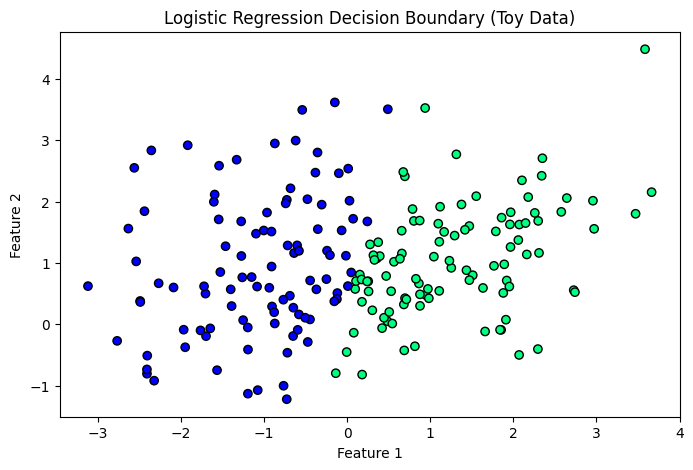

Toy Data Accuracy: 84.00%


In [7]:
# Generate synthetic data
from sklearn.datasets import make_classification
X_toy, y_toy = make_classification(n_samples=200, n_features=2, n_redundant=0, 
                                    n_informative=2, n_clusters_per_class=1, random_state=42)

# Train the model
toy_model = LogisticRegression(learning_rate=0.1, epochs=1000)
toy_model.fit(X_toy, y_toy)
toy_preds = toy_model.predict(X_toy)

# Plotting decision boundary
plt.figure(figsize=(8, 5))
plt.scatter(X_toy[:, 0], X_toy[:, 1], c=toy_preds, cmap='winter', edgecolors='k')
plt.title("Logistic Regression Decision Boundary (Toy Data)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print(f"Toy Data Accuracy: {accuracy_score(y_toy, toy_preds) * 100:.2f}%")

## 2. Real-World Application: Agricultural Yield Prediction
We will now use the `agriculture.csv` dataset. Our goal is to classify whether a region will have a **High Yield** (1) or **Low Yield** (0) based on features like Precipitation, Temperature, Soil Health, and Fertilizer use.

In [10]:
# Load the dataset
df = pd.read_csv('../data/agriculture.csv')

# Create binary target: 1 if Yield is above median, 0 otherwise
median_yield = df['Crop_Yield_MT_per_HA'].median()
df['Yield_Binary'] = (df['Crop_Yield_MT_per_HA'] > median_yield).astype(int)

# Select features for classification
features = [
    'Average_Temperature_C', 'Total_Precipitation_mm', 'CO2_Emissions_MT', 
    'Extreme_Weather_Events', 'Irrigation_Access_%', 'Pesticide_Use_KG_per_HA', 
    'Fertilizer_Use_KG_per_HA', 'Soil_Health_Index'
]

X = df[features].values
y = df['Yield_Binary'].values

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (Critical for Logistic Regression!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# Initialize and train the model
log_reg = LogisticRegression(learning_rate=0.05, epochs=2000)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)

# Results
print("--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- Logistic Regression Performance ---
Accuracy: 0.5850

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.60      0.59       983
           1       0.60      0.57      0.58      1017

    accuracy                           0.58      2000
   macro avg       0.59      0.59      0.58      2000
weighted avg       0.59      0.58      0.58      2000



## Conclusion
- The Logistic Regression model successfully classified yield levels.
- Unlike the Perceptron (which only looks for a boundary), Logistic Regression uses the Sigmoid function to handle overlapping data points more effectively through probabilities.
- Feature scaling was essential to prevent the Gradient Descent from diverging.